## ZTF combined observing log
This notebook combines the Metadata DB from [ZTF public data release](https://irsa.ipac.caltech.edu/data/ZTF/docs/releases/ztf_release_notes_latest) and the observing log from [Rigault et al. 2025](https://ui.adsabs.harvard.edu/abs/2025A%26A...694A...1R/abstract) to obtain all columns needed for simulating ZTF light curves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ
from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable, _ztfcam_ccd_gain, _ztfcam_readout_noise
from lightcurvelynx.astro_utils.mag_flux import mag2flux
from lightcurvelynx.astro_utils.noise_model import poisson_bandflux_std
import sqlite3
from astropy.time import Time
from utils.analysis_utils import compute_sky
import inspect
from IPython.display import display, Markdown

In [2]:
con = sqlite3.connect("data/ztf_metadata_latest.db")
sql_query = "SELECT * FROM exposures"
metadata_table = pd.read_sql_query(sql_query, con)
metadata_table = metadata_table.replace("", np.nan)
metadata_table = metadata_table.dropna(subset=["fwhm"])
metadata_table.columns

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_12993/2534340399.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata_table = metadata_table.replace("", np.nan)


Index(['expid', 'field', 'filter', 'obsdate', 'ra', 'dec', 'exptime',
       'airmass', 'infobits', 'dr', 'numsci', 'numdiff', 'fwhm', 'maglim',
       'scibckgnd', 'ellip', 'ellippa'],
      dtype='object')

In [3]:
metadata_table.obsdate.min(), metadata_table.obsdate.max()

('2018-03-20 02:58:21.000', '2023-10-30 13:09:24.220')

Since the obs_log is given per ccd quadrant, we select the median value for zp and maglimit. Other rows are dropped out to avoid duplicate observations.

In [4]:
obs_log = pd.read_parquet('ztfsniadr2/tables/observing_logs.parquet')
# assign median of zp across ccd for that expid
obs_log = obs_log.assign(
    zp = obs_log.groupby(['expid'])['zp'].transform('median')
)
obs_log = obs_log.assign(
    maglimit = obs_log.groupby(['expid'])['maglimit'].transform('median')
)
obs_log = obs_log.drop_duplicates("expid")

In [5]:
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
0,58288.171875,ztfi,375,3.787257,-0.171915,16,19.430910,25.608532,6.2,53417042,0,49.960846
64,58288.171875,ztfi,427,3.850371,-0.046251,16,19.500843,25.606779,6.2,53417087,0,48.465134
128,58288.171875,ztfi,478,3.833042,0.079412,17,19.760248,25.611835,6.2,53417134,0,40.872425
192,58288.171875,ztfi,529,3.754645,0.205076,16,20.177334,25.619251,6.2,53417179,0,29.095768
256,58288.171875,ztfi,580,3.774032,0.330740,17,20.488144,25.632843,6.2,53417225,0,22.899696
...,...,...,...,...,...,...,...,...,...,...,...,...
32808178,59273.554688,ztfr,490,5.273359,0.079412,22,18.220627,26.118870,6.3,151955548,0,270.041229
32808242,59273.554688,ztfr,438,5.208885,-0.046251,18,18.245682,26.107391,6.4,151955596,0,307.489014
32808306,59273.554688,ztfr,642,5.511889,0.456404,17,18.122261,26.124512,6.5,151955651,0,320.501190
32808370,59273.558594,ztfr,593,5.421456,0.330740,22,18.064224,26.137409,6.3,151955697,33554440,447.744232


In [6]:
print(f"The obs_log covers mjd from {obs_log.mjd.min()} to {obs_log.mjd.max()}")
t = Time([obs_log.mjd.min(),obs_log.mjd.max()], format='mjd', scale='utc')
print(t.to_datetime())

The obs_log covers mjd from 58288.171875 to 59273.55859375
[datetime.datetime(2018, 6, 19, 4, 7, 30)
 datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)]


In [7]:
obs_log["filter"] = obs_log.apply(lambda row: row["band"][-1],axis=1)
obs_log = pd.merge(obs_log, metadata_table[["expid","filter","exptime","fwhm","obsdate","scibckgnd","ra","dec","maglim","airmass"]],on=["filter","expid"])
gain = _ztfcam_ccd_gain
obs_log["zp_nJy"] = mag2flux(obs_log["zp"].values + 2.5*np.log10(gain))
obs_log = obs_log.rename(columns={"zp":"zp_abmag"})

In [8]:
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,filter,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,airmass,zp_nJy
0,58288.171875,ztfi,375,3.787257,-0.171915,16,19.430910,25.608532,6.2,53417042,...,i,30.0,3.467395,2018-06-19 04:05:25.548,334.3445,216.993833,-9.85,19.16130,1.385,33.434554
1,58288.171875,ztfi,427,3.850371,-0.046251,16,19.500843,25.606779,6.2,53417087,...,i,30.0,3.543785,2018-06-19 04:06:04.871,297.5000,220.610000,-2.65,19.13055,1.256,33.488575
2,58288.171875,ztfi,478,3.833042,0.079412,17,19.760248,25.611835,6.2,53417134,...,i,30.0,2.973075,2018-06-19 04:06:44.296,329.7940,219.617125,4.55,19.37485,1.154,33.332978
3,58288.171875,ztfi,529,3.754645,0.205076,16,20.177334,25.619251,6.2,53417179,...,i,30.0,2.407530,2018-06-19 04:07:23.921,234.9170,215.125333,11.75,19.60345,1.079,33.106084
4,58288.171875,ztfi,580,3.774032,0.330740,17,20.488144,25.632843,6.2,53417225,...,i,30.0,2.076620,2018-06-19 04:08:03.345,232.5710,216.236083,18.95,19.92260,1.036,32.694229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522192,59273.554688,ztfr,490,5.273359,0.079412,22,18.220627,26.118870,6.3,151955548,...,r,30.0,4.445800,2021-02-28 13:19:54.776,142.7340,302.141208,4.55,18.28955,2.192,20.895867
522193,59273.554688,ztfr,438,5.208885,-0.046251,18,18.245682,26.107391,6.4,151955596,...,r,30.0,4.250080,2021-02-28 13:20:35.531,178.6410,298.447125,-2.65,18.28400,2.292,21.117950
522194,59273.554688,ztfr,642,5.511889,0.456404,17,18.122261,26.124512,6.5,151955651,...,r,30.0,4.535925,2021-02-28 13:21:23.577,129.9455,315.808000,26.15,18.19900,2.201,20.787565
522195,59273.558594,ztfr,593,5.421456,0.330740,22,18.064224,26.137409,6.3,151955697,...,r,30.0,4.731005,2021-02-28 13:22:04.025,132.0290,310.626542,18.95,18.17925,2.121,20.542090


In [9]:
t = Time([obs_log.mjd.min(),obs_log.mjd.max()], format='mjd', scale='utc')
print(t.to_datetime())

[datetime.datetime(2018, 6, 19, 4, 7, 30)
 datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)]


In [10]:
# remove wrong ra/dec values 
print("before:",len(obs_log))
idx = obs_log.ra<0
display(obs_log.loc[idx])
obs_log = obs_log.loc[~idx]
print("after",len(obs_log))

before: 522197


,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,filter,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,airmass,zp_nJy
112646,58493.554688,ztfg,1620,3.100007,0.393572,17,22.064384,26.278151,6.2,73955409,...,g,30.0,1.933235,2019-01-10 13:17:54.175,154.36300,-149985.0,-9999.0,21.37715,1.045,18.044634
140094,58577.445312,ztfr,588,4.788912,0.330740,17,16.946423,22.173155,6.2,82344436,...,r,30.0,1.814035,2019-04-04 10:39:53.285,3.76500,-149985.0,-9999.0,16.28595,1.260,791.309497
197317,58698.285156,ztfr,865,4.817109,1.336050,21,19.883492,24.979687,6.2,94428439,...,r,30.0,1.784935,2019-08-03 06:49:32.285,72.45985,-149985.0,-9999.0,19.29150,1.397,59.666919
226618,58743.390625,ztfg,852,5.834386,1.210386,17,19.752502,26.102474,6.2,98939162,...,g,30.0,2.756865,2019-09-17 09:23:56.285,91.55705,-149985.0,-9999.0,19.66060,1.389,21.213808
270140,58799.511719,ztfg,701,1.100809,0.707731,18,19.316364,26.125084,6.4,104551297,...,g,30.0,2.096860,2019-11-12 12:18:41.764,90.42550,-149985.0,-9999.0,19.15680,1.398,20.776613


after 522192


In [11]:
obs_log.infobits.unique()

array([       0,        8,  2097152,     2056,        1, 33554440,
           2072,     2048,       48,     2096,       32,     2080,
           2088,        9,       49,     2049,       51,       24,
             40,     2104,       56,     2097,     2065,     2099,
           2083,     2050,        2,        3,       19,       57,
             17,       59,     2081,       33,     2051,     2067,
             16,       35, 33554480, 33554432, 33554464, 33556480,
       33556512, 33556528,       41,       25,  4194304,      513,
       37748736, 35651584,  2097153, 33554481,     2073,     2075,
        2097171,       50,  2099202,  2099200,      512,  4194312,
        4194336,  4194352,  4194305,  4194353,  4194816,      520,
        4196352,  6291456,  4194313, 37750840, 33554433, 33554944,
       33554456, 33554488, 33554457, 37748744, 33554489, 37748785,
       37748739, 33556513, 33556529, 33554435, 33554483, 37750835,
       33556531, 33554448, 33554441, 33556488], dtype=uint32)

(array([4.95795e+05, 8.09100e+03, 1.06060e+04, 7.60000e+01, 2.76700e+03,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 2.78000e+03, 2.07700e+03]),
 array([0.        , 0.75769266, 1.51538533, 2.27307799, 3.03077065,
        3.78846332, 4.54615598, 5.30384864, 6.0615413 , 6.81923397,
        7.57692663]),
 <BarContainer object of 10 artists>)

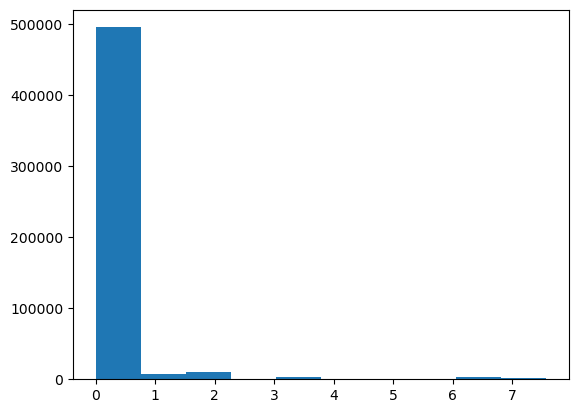

In [12]:
plt.hist(np.log10(obs_log.infobits+1))

In [13]:
# # remove bad quality epochs
# # page 4 of https://irsa.ipac.caltech.edu/data/ZTF/docs/ztf_extended_cautionary_notes.
# # " If INFOBITS for an image has value < 33554432 (i.e., does not contain bit 25), the image and catalog data are probably usable. "

# # but ztf sn data has a flag to remove all that have infobits > 0. let's try that.

# print("before:", len(obs_log))
# # obs_log = obs_log.loc[obs_log.infobits < 33554432]
# obs_log = obs_log.loc[obs_log.infobits == 0]
# print("after:", len(obs_log))

In [14]:
# # let's try to derive skynoise using maglim and zp
# # snr = flux/fluxerr
# # fluxerr = sqrt(flux + sky_adu*npix*gain + readnoise**2*nexposure*npix + darkcurrent*npix*exptime*nexposure)
# # 5 = flux/fluxerr
# # 25 = flux**2/(flux + sky_adu*npix*gain + readnoise**2*nexposure*npix + darkcurrent*npix*exptime*nexposure)
# # flux**2 - 25*flux -25*( sky_adu*npix*gain
# #                         + readnoise**2*nexposure*npix
# #                         + darkcurrent*npix*exptime*nexposure)
# #                     = 0
# # flux_e = 10^(-0.4*(maglim-zp))*gain
# # sky_adu*npix*gain =  (flux_e**2 / 25 - flux_e - (readnoise**2*nexposure*npix
# #                              + darkcurrent*npix*exptime*nexposure))
# def compute_sky(row):
#     gain = _ztfcam_ccd_gain
#     nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
#     flux = np.power(10., -0.4*(row['maglim'] - row['zp_abmag'])) * gain
#     sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
#     return sky                          

In [15]:
# The sky background is computed using the compute_sky function
display(Markdown(f"```python\n{inspect.getsource(compute_sky)}\n```"))

```python
def compute_sky(row):
    gain = _ztfcam_ccd_gain
    nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
    flux = np.power(10., -0.4*(row['maglimit'] - row['zp_abmag'])) * gain
    sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
    return sky    

```

In [16]:
obs_log["sky_adu"] = obs_log.apply(compute_sky,axis=1)

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_12993/605690609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_log["sky_adu"] = obs_log.apply(compute_sky,axis=1)


In [17]:
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,airmass,zp_nJy,sky_adu
0,58288.171875,ztfi,375,3.787257,-0.171915,16,19.430910,25.608532,6.2,53417042,...,30.0,3.467395,2018-06-19 04:05:25.548,334.3445,216.993833,-9.85,19.16130,1.385,33.434554,775.433778
1,58288.171875,ztfi,427,3.850371,-0.046251,16,19.500843,25.606779,6.2,53417087,...,30.0,3.543785,2018-06-19 04:06:04.871,297.5000,220.610000,-2.65,19.13055,1.256,33.488575,648.246559
2,58288.171875,ztfi,478,3.833042,0.079412,17,19.760248,25.611835,6.2,53417134,...,30.0,2.973075,2018-06-19 04:06:44.296,329.7940,219.617125,4.55,19.37485,1.154,33.332978,573.052843
3,58288.171875,ztfi,529,3.754645,0.205076,16,20.177334,25.619251,6.2,53417179,...,30.0,2.407530,2018-06-19 04:07:23.921,234.9170,215.125333,11.75,19.60345,1.079,33.106084,404.375540
4,58288.171875,ztfi,580,3.774032,0.330740,17,20.488144,25.632843,6.2,53417225,...,30.0,2.076620,2018-06-19 04:08:03.345,232.5710,216.236083,18.95,19.92260,1.036,32.694229,309.271432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522192,59273.554688,ztfr,490,5.273359,0.079412,22,18.220627,26.118870,6.3,151955548,...,30.0,4.445800,2021-02-28 13:19:54.776,142.7340,302.141208,4.55,18.28955,2.192,20.895867,11488.055794
522193,59273.554688,ztfr,438,5.208885,-0.046251,18,18.245682,26.107391,6.4,151955596,...,30.0,4.250080,2021-02-28 13:20:35.531,178.6410,298.447125,-2.65,18.28400,2.292,21.117950,11751.480370
522194,59273.554688,ztfr,642,5.511889,0.456404,17,18.122261,26.124512,6.5,151955651,...,30.0,4.535925,2021-02-28 13:21:23.577,129.9455,315.808000,26.15,18.19900,2.201,20.787565,13371.708471
522195,59273.558594,ztfr,593,5.421456,0.330740,22,18.064224,26.137409,6.3,151955697,...,30.0,4.731005,2021-02-28 13:22:04.025,132.0290,310.626542,18.95,18.17925,2.121,20.542090,14010.202973


In [18]:
obs_log.to_parquet("data/ztf_observing_log_combined_w_metadata.parquet")

In [19]:
obs_log.columns

Index(['mjd', 'band', 'fieldid', 'fieldra', 'fielddec', 'rcid', 'maglimit',
       'zp_abmag', 'gain', 'expid', 'infobits', 'skynoise', 'filter',
       'exptime', 'fwhm', 'obsdate', 'scibckgnd', 'ra', 'dec', 'maglim',
       'airmass', 'zp_nJy', 'sky_adu'],
      dtype='object')

-0.38784048985823055


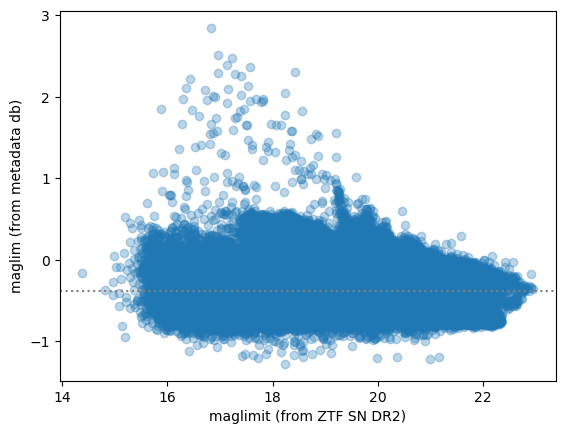

In [20]:
plt.plot(obs_log.maglimit, obs_log.maglim - obs_log.maglimit,'o',alpha=0.3)
plt.axhline(y=np.mean(obs_log.maglim - obs_log.maglimit),ls=':',c='gray')
plt.xlabel('maglimit (from ZTF SN DR2)')
plt.ylabel('maglim (from metadata db)')
print(np.mean(obs_log.maglim - obs_log.maglimit))

In [21]:
def calculate_median_cadence(mjd):
    mjd = np.sort(mjd)
    return np.median(np.diff(mjd))

In [22]:
median_cadence_per_field = obs_log.groupby(['fieldid','band'])["mjd"].apply(calculate_median_cadence)
median_cadence_per_field.median()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


2.017578125

<Axes: >

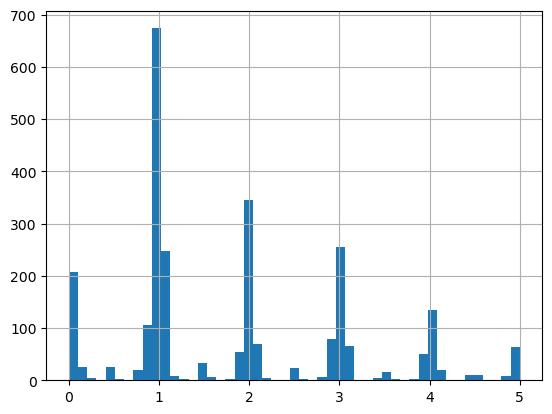

In [23]:
median_cadence_per_field.hist(bins=np.linspace(0,5))

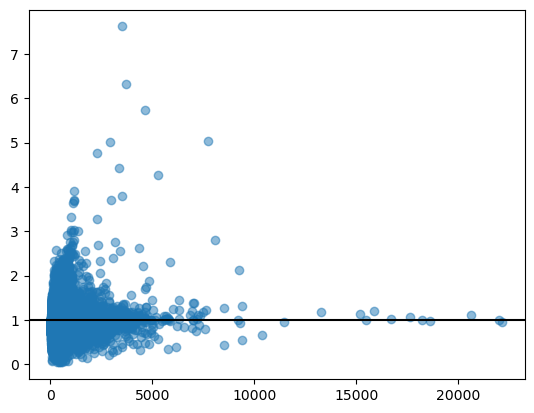

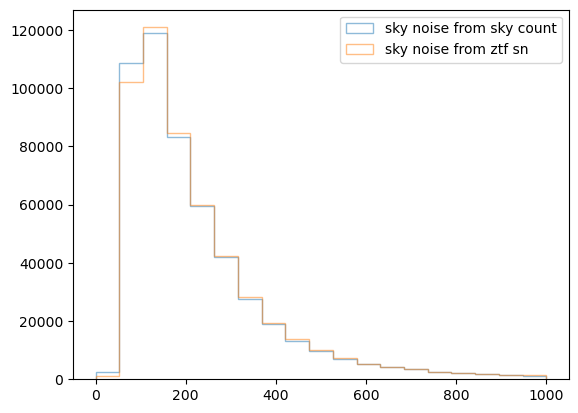

In [24]:
nea = GAUSS_EFF_AREA2FWHM_SQ * (obs_log["fwhm"]) ** 2

plt.plot(np.sqrt(obs_log["sky_adu"]*6.2*nea),np.sqrt(obs_log["sky_adu"]*6.2*nea)/(obs_log["skynoise"]*6.2),'o',alpha=0.5)
plt.axhline(y=1,c='k')
plt.show()
bins = np.linspace(0,1e3,20)
plt.hist(np.sqrt(obs_log["sky_adu"]*6.2*nea),bins=bins,alpha=0.5,label='sky noise from sky count',histtype='step')
plt.hist(obs_log["skynoise"]*6.2,bins=bins,alpha=0.5,label='sky noise from ztf sn',histtype='step') #skynoise = 1/5 * 10^(-0.4(maglim - magzp)) in ADU
plt.legend()